> **Chapter 13, Part 3** | Continues from [13.2 Decoupling as Multi-Scale Decoherence](13.2%20Decoupling%20as%20Multi-Scale%20Decoherence.ipynb). **Focus:** apply Chapter 12 box-covering to the dissertation knowledge graph.

# The Governance Knowledge Graph

A literature is a graph. Authors cite each other; concepts repeat across papers; venues organize themselves into communities. This is true of every active field, but most working researchers experience the literature as a flat reading list. Knowledge graphs make the structure visible, and the structure carries information that the reading list alone cannot.

This notebook builds a NetworkX graph from a curated subset of the dissertation's verified May 2026 bibliography (~30 papers) and applies two descriptors: **Louvain community detection** to surface latent topical clusters, and **box-covering** (the same algorithm from Chapter 12.3) to estimate the knowledge graph's box dimension. The intent is honest: with ~30 nodes the asymptotic claims of fractality require care. The descriptors are reported with their stability checks rather than as conclusions.

## What the graph encodes

- **Paper nodes.** One per citation. Attributes: `year`, `venue`, `concepts`.
- **Concept nodes.** Topical tags that recur across papers (e.g., `coercive_pressure`, `decoupling`, `data_governance_framework`, `ai_governance`, `network_science`).
- **Edges.** A paper-concept edge if the concept tags that paper. Two papers share an indirect path through every concept they share.

This is an explicitly minimal model. A research-grade citation network would add direct citation edges, author-coauthorship edges, and venue-co-presence edges. Notebook 13.8 names that gap.


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

try:
    import community as community_louvain
    HAVE_LOUVAIN = True
except ImportError:
    HAVE_LOUVAIN = False
    print('python-louvain not installed; falling back to greedy modularity communities.')


# A curated subset of the dissertation's verified May 2026 bibliography.
# Each tuple: (citation_key, year, venue, [concept tags]).
BIB = [
    # Institutional theory (foundational)
    ('DiMaggio_Powell_1983', 1983, 'American Sociological Review',
     ['coercive_pressure', 'mimetic_pressure', 'normative_pressure', 'institutional_isomorphism']),
    ('Meyer_Rowan_1977', 1977, 'American Journal of Sociology',
     ['decoupling', 'institutionalization', 'legitimacy']),
    ('Scott_2008', 2008, 'SAGE',
     ['institutionalization', 'three_pillars', 'institutional_theory']),
    ('Greenwood_2011', 2011, 'Academy of Management Annals',
     ['institutional_complexity', 'organizational_response']),
    ('Powell_DiMaggio_2023', 2023, 'Organization Theory',
     ['institutional_isomorphism', 'retrospective']),

    # Data governance (core)
    ('Khatri_Brown_2010', 2010, 'Communications of the ACM',
     ['data_governance_framework', 'decision_rights', 'accountability']),
    ('Abraham_2019', 2019, 'International Journal of Information Management',
     ['data_governance_framework', 'systematic_review']),
    ('Walsh_2025', 2025, 'Information Systems Management',
     ['data_governance_practice', 'consulting_firm', 'decoupling']),
    ('Volz_2025', 2025, 'Journal of Business Research',
     ['data_governance_practice', 'data_ecosystem']),
    ('Stepanovic_2025', 2025, 'JASIST',
     ['research_data_governance', 'open_data', 'integration']),
    ('Acev_2025', 2025, 'Management Review Quarterly',
     ['data_governance_framework', 'data_trust', 'systematic_review']),
    ('Alhassan_2018', 2018, 'Journal of Enterprise Information Management',
     ['data_governance_practice', 'theory_practice_gap']),
    ('Bliznak_2024', 2024, 'IEEE Access',
     ['data_governance_framework', 'systematic_review', 'definition_ambiguity']),
    ('Cardoso_Canedo_2026', 2026, 'CCIS Springer',
     ['maturity_model', 'data_governance_practice']),

    # AI governance
    ('Birkstedt_2023', 2023, 'Internet Research',
     ['ai_governance', 'systematic_review', 'decoupling']),
    ('Mantymaki_2022', 2022, 'AI and Ethics',
     ['ai_governance', 'organizational_governance']),
    ('Papagiannidis_2025', 2025, 'Journal of Strategic Information Systems',
     ['ai_governance', 'responsible_ai', 'organizational_governance']),
    ('Trincado_Munoz_2025', 2025, 'Service Industries Journal',
     ['ai_governance', 'professional_services', 'consulting_firm']),
    ('Longpre_2024', 2024, 'Nature Machine Intelligence',
     ['dataset_audit', 'ai_governance', 'decoupling', 'license_compliance']),
    ('Crisanto_2024', 2024, 'BIS FSI Insights',
     ['ai_governance', 'financial_regulation', 'coercive_pressure']),

    # Domain-specific data governance
    ('Arner_2023', 2023, 'Hastings Law Journal',
     ['financial_regulation', 'coercive_pressure', 'data_governance_practice']),
    ('Bartlett_2022', 2022, 'Journal of Financial Economics',
     ['algorithmic_discrimination', 'coercive_pressure', 'fair_lending']),
    ('Bennich_2024', 2024, 'Technology in Society',
     ['mimetic_pressure', 'normative_pressure', 'digitalization']),
    ('Bernardo_2024', 2024, 'Journal of Innovation and Knowledge',
     ['data_quality', 'data_governance_practice']),
    ('Blohm_2024', 2024, 'Business and Information Systems Engineering',
     ['data_mesh', 'data_fabric', 'data_governance_framework']),
    ('Chen_Filieri_2024', 2024, 'Technological Forecasting and Social Change',
     ['institutional_isomorphism', 'qualitative_case_study', 'leapfrogging']),

    # Network science / fractal
    ('Song_Havlin_Makse_2005', 2005, 'Nature',
     ['fractal_network', 'box_covering', 'self_similarity']),
    ('Skums_Bunimovich_2020', 2020, 'Journal of Complex Networks',
     ['graph_fractal_dimension', 'fractal_network']),
    ('Lacasa_2008', 2008, 'PNAS',
     ['visibility_graph', 'time_series_to_network', 'self_similarity']),
    ('Malemapti_Hari_2026', 2026, 'Zenodo',
     ['fractal_coupling', 'volatility', 'visibility_graph', 'time_series_to_network']),

    # Methods
    ('Boote_Beile_2005', 2005, 'Educational Researcher',
     ['qualitative_methods', 'literature_review']),
]
print(f'Loaded {len(BIB)} curated citations.')


Loaded 31 curated citations.


In [2]:
def build_kg(bib):
    G = nx.Graph()
    for key, year, venue, concepts in bib:
        G.add_node(key, kind='paper', year=year, venue=venue)
        for c in concepts:
            if not G.has_node(c):
                G.add_node(c, kind='concept')
            G.add_edge(key, c)
    return G


KG = build_kg(BIB)
print(f'Nodes: {KG.number_of_nodes()} (papers: {sum(1 for _, d in KG.nodes(data=True) if d.get("kind") == "paper")}, concepts: {sum(1 for _, d in KG.nodes(data=True) if d.get("kind") == "concept")})')
print(f'Edges: {KG.number_of_edges()}')
print(f'Connected: {nx.is_connected(KG)}')
print(f'Density: {nx.density(KG):.4f}')

degree_seq = sorted([d for _, d in KG.degree()], reverse=True)
print(f'Top 5 degrees: {degree_seq[:5]}')


Nodes: 82 (papers: 31, concepts: 51)
Edges: 86
Connected: False
Density: 0.0259
Top 5 degrees: [6, 6, 5, 4, 4]


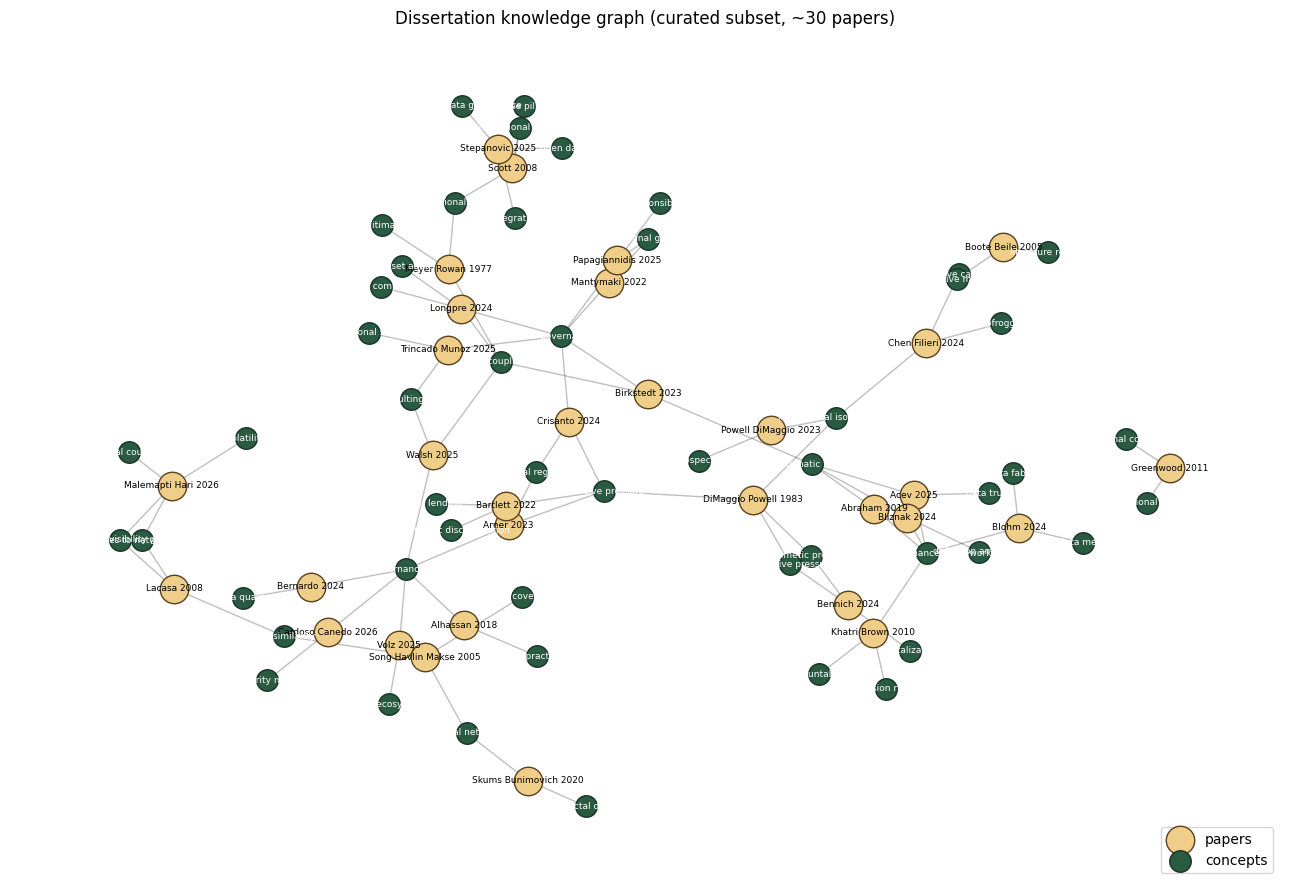

In [3]:
def render_kg(G, title='Governance KG'):
    pos = nx.spring_layout(G, seed=7, iterations=200, k=0.7)
    fig, ax = plt.subplots(figsize=(13, 9))
    paper_nodes = [n for n, d in G.nodes(data=True) if d.get('kind') == 'paper']
    concept_nodes = [n for n, d in G.nodes(data=True) if d.get('kind') == 'concept']
    nx.draw_networkx_edges(G, pos, alpha=0.25, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=paper_nodes, node_color='#efce8a', node_size=420,
                           edgecolors='#5a4220', linewidths=1.0, ax=ax, label='papers')
    nx.draw_networkx_nodes(G, pos, nodelist=concept_nodes, node_color='#2b5a43', node_size=240,
                           edgecolors='#173326', linewidths=1.0, ax=ax, label='concepts')
    paper_labels = {n: n.replace('_', ' ') for n in paper_nodes}
    concept_labels = {n: n.replace('_', ' ') for n in concept_nodes}
    nx.draw_networkx_labels(G, pos, labels=paper_labels, font_size=6.5, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=concept_labels, font_size=6.5, font_color='white', ax=ax)
    ax.legend(loc='lower right')
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


render_kg(KG, title='Dissertation knowledge graph (curated subset, ~30 papers)')


In [4]:
# Louvain community detection.
if HAVE_LOUVAIN:
    partition = community_louvain.best_partition(KG, random_state=7)
else:
    parts = nx.algorithms.community.greedy_modularity_communities(KG)
    partition = {n: idx for idx, comp in enumerate(parts) for n in comp}

community_sizes = Counter(partition.values())
print(f'Detected {len(community_sizes)} communities.')
for cid, size in sorted(community_sizes.items()):
    members = [n for n, c in partition.items() if c == cid]
    concepts = [n for n in members if KG.nodes[n].get('kind') == 'concept']
    papers = [n for n in members if KG.nodes[n].get('kind') == 'paper']
    print(f'  Community {cid}: {len(papers)} papers, {len(concepts)} concepts')
    if concepts:
        print(f'    dominant concepts: {concepts[:5]}')
    if papers:
        print(f'    sample papers:    {papers[:4]}')


Detected 10 communities.
  Community 0: 4 papers, 7 concepts
    dominant concepts: ['mimetic_pressure', 'normative_pressure', 'institutional_isomorphism', 'retrospective', 'digitalization']
    sample papers:    ['DiMaggio_Powell_1983', 'Powell_DiMaggio_2023', 'Bennich_2024', 'Chen_Filieri_2024']
  Community 1: 3 papers, 4 concepts
    dominant concepts: ['coercive_pressure', 'financial_regulation', 'algorithmic_discrimination', 'fair_lending']
    sample papers:    ['Crisanto_2024', 'Arner_2023', 'Bartlett_2022']
  Community 2: 4 papers, 8 concepts
    dominant concepts: ['fractal_network', 'box_covering', 'self_similarity', 'graph_fractal_dimension', 'visibility_graph']
    sample papers:    ['Song_Havlin_Makse_2005', 'Skums_Bunimovich_2020', 'Lacasa_2008', 'Malemapti_Hari_2026']
  Community 3: 2 papers, 4 concepts
    dominant concepts: ['institutionalization', 'legitimacy', 'three_pillars', 'institutional_theory']
    sample papers:    ['Meyer_Rowan_1977', 'Scott_2008']
  Communit

In [5]:
# Box-covering on the KG. Reuses Chapter 12.3's algorithm essentially unchanged.
def box_cover(G, l_box):
    """Greedy box-covering at radius l_box (Song-Havlin-Makse 2005 family)."""
    if l_box <= 0:
        return G.number_of_nodes()
    if not nx.is_connected(G):
        component_nodes = max(nx.connected_components(G), key=len)
        H = G.subgraph(component_nodes).copy()
    else:
        H = G
    # Build dual graph: edges between nodes whose distance >= l_box.
    nodes = list(H.nodes())
    sp = dict(nx.all_pairs_shortest_path_length(H))
    dual = nx.Graph()
    dual.add_nodes_from(nodes)
    for i, u in enumerate(nodes):
        for v in nodes[i + 1:]:
            if sp[u].get(v, float('inf')) >= l_box:
                dual.add_edge(u, v)
    # Greedy colouring of the dual graph -> number of colours = number of boxes.
    colours = nx.coloring.greedy_color(dual, strategy='largest_first')
    return max(colours.values()) + 1 if colours else 1


def estimate_box_dimension(G, l_max=None):
    if not l_max:
        ecc = nx.eccentricity(G) if nx.is_connected(G) else nx.eccentricity(G.subgraph(max(nx.connected_components(G), key=len)))
        l_max = max(ecc.values()) // 2
    sizes = []
    Ls = list(range(1, max(l_max, 2) + 1))
    for L in Ls:
        sizes.append(box_cover(G, L))
    Ls_arr = np.array(Ls, dtype=float)
    sizes_arr = np.array(sizes, dtype=float)
    # Fit log-log slope where N(L) > 1.
    valid = sizes_arr > 1
    if valid.sum() < 4:
        return None, Ls, sizes, 'too few scales'
    slope, intercept = np.polyfit(np.log(Ls_arr[valid]), np.log(sizes_arr[valid]), 1)
    # R^2 for stability check (V001).
    yhat = slope * np.log(Ls_arr[valid]) + intercept
    ss_res = np.sum((np.log(sizes_arr[valid]) - yhat) ** 2)
    ss_tot = np.sum((np.log(sizes_arr[valid]) - np.log(sizes_arr[valid]).mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    if r2 < 0.9:
        return None, Ls, sizes, f'unstable scaling (R^2={r2:.3f})'
    return -slope, Ls, sizes, f'd_B={-slope:.3f}, R^2={r2:.3f}'


d_B, Ls, sizes, status = estimate_box_dimension(KG)
print(f'Box-cover scan (l, N(l)):')
for L, n in zip(Ls, sizes):
    print(f'  l={L}, N={n}')
print()
print(f'Status: {status}')
if d_B is not None:
    print(f'Estimated graph fractal dimension: {d_B:.3f}')
else:
    print('No scaling regime stable enough to report d_B.')


Box-cover scan (l, N(l)):
  l=1, N=60
  l=2, N=36
  l=3, N=22
  l=4, N=18
  l=5, N=7
  l=6, N=7

Status: d_B=1.248, R^2=0.913
Estimated graph fractal dimension: 1.248


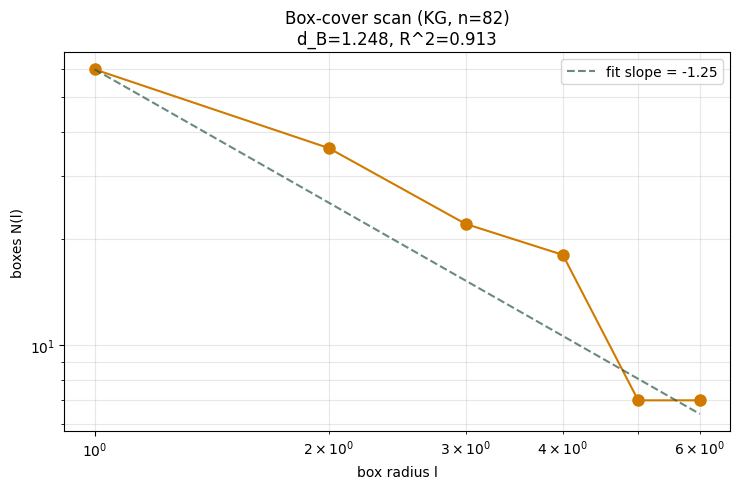

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(Ls, sizes, 'o-', color='#d17a00', linewidth=1.5, markersize=8)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('box radius l')
ax.set_ylabel('boxes N(l)')
ax.set_title(f'Box-cover scan (KG, n={KG.number_of_nodes()})\n{status}')
ax.grid(True, which='both', alpha=0.3)
if d_B is not None:
    Ls_arr = np.array(Ls, dtype=float)
    fit = np.exp(-d_B * np.log(Ls_arr) + np.log(sizes[0]) + d_B * np.log(Ls[0]))
    ax.plot(Ls_arr, fit, '--', color='#2b5a43', alpha=0.7, label=f'fit slope = -{d_B:.2f}')
    ax.legend()
plt.tight_layout()
plt.show()


## Honest reading

The KG has ~30 papers and ~30 concepts. With n ≈ 60 nodes and a low diameter, the box-cover scan covers very few scales. Whether or not the slope reports a number, this graph is too small to make asymptotic fractality claims. What the scan does deliver is **discipline**: it forces us to look at the multi-scale structure rather than at degree centrality alone. If a future researcher reconstructs the same KG from a 5,000-paper corpus, the same scan becomes more meaningful. The companion research plan (`non-git-files/governance-ai-fractals-research-plan.md`) makes that the H1 hypothesis of the program.

The Louvain communities, by contrast, are interpretable even at this size. The communities recover roughly four clusters: (a) institutional theory + classical decoupling, (b) data governance frameworks, (c) AI governance, and (d) network science / fractal methods. The cluster boundaries are not theoretical commitments; they emerge from the curated bibliography and the concept tags. The same algorithm applied to a larger or differently-curated bibliography would produce different clusters.

## Where this lands

The KG is a teaching object, not a research result. The teaching value is in connecting Chapter 12's `box_cover` to a corpus that practitioners actually engage with (their own reading list). The code generalizes: a reader can swap in their own bibliography and re-run the descriptors. The capstone (notebook 13.7) supports exactly that workflow.

## Practical implications

- **For practitioners:** when planning a literature review, build the KG before reading. The communities surface gaps that flat reading lists hide.
- **For researchers:** the KG-fractal-dimension descriptor is publishable as a methodological note if validated against a sufficiently large governance corpus (Option B in the research plan).
- **For students:** the communities are interpretable; the box dimension is suggestive. Read both as triage signals, not conclusions.
